In [93]:
import pandas as pd
import numpy as np
from tensorflow.keras.layers import Embedding, LSTM, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [94]:
df = pd.read_csv("/kaggle/input/datasets/harshitsinghpatel/tweetss/Tweets.csv")
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [95]:
df['text'] = df['text'].astype(str).str.lower()
df = df.dropna()
df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"i`d have responded, if i were going","I`d have responded, if I were going",neutral
1,549e992a42,sooo sad i will miss you here in san diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [96]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['text'])

In [97]:
X = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(X,maxlen=50)

In [98]:
y = df['sentiment'].map({
    'neutral':1,
    'negative':0,
    'positive':2
})

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [100]:
rnn_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=50, mask_zero=True),
    Bidirectional(SimpleRNN(64, dropout=0.3)),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [101]:
lstm_model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=50),
    LSTM(128, dropout= 0.3, recurrent_dropout=0.2),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [102]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,              # stop if no improvement for 3 epochs
        restore_best_weights=True # use best epoch's weights
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,             # halve the learning rate
        patience=2,
        min_lr=1e-6
    )
]

In [103]:
rnn_history = rnn_model.fit(X_train, y_train,
                           epochs=3,
                           batch_size=64,
                           validation_split=0.2)

Epoch 1/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.4476 - loss: 1.0347 - val_accuracy: 0.6736 - val_loss: 0.7595
Epoch 2/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7405 - loss: 0.6311 - val_accuracy: 0.6814 - val_loss: 0.7252
Epoch 3/3
275/275 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8549 - loss: 0.3981 - val_accuracy: 0.6684 - val_loss: 0.8721


In [104]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 45s 151ms/step - accuracy: 0.4981 - loss: 0.9916 - val_accuracy: 0.6962 - val_loss: 0.7274 - learning_rate: 0.0010
Epoch 2/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 41s 148ms/step - accuracy: 0.7368 - loss: 0.6404 - val_accuracy: 0.7134 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 3/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 42s 151ms/step - accuracy: 0.8162 - loss: 0.4941 - val_accuracy: 0.7055 - val_loss: 0.7046 - learning_rate: 0.0010
Epoch 4/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 42s 154ms/step - accuracy: 0.8487 - loss: 0.4181 - val_accuracy: 0.6850 - val_loss: 0.7654 - learning_rate: 0.0010
Epoch 5/30
275/275 ━━━━━━━━━━━━━━━━━━━━ 42s 154ms/step - accuracy: 0.8829 - loss: 0.3409 - val_accuracy: 0.6889 - val_loss: 0.8295 - learning_rate: 5.0000e-04


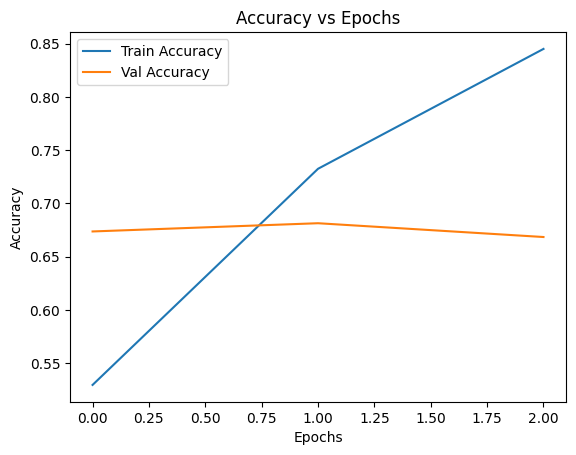

In [105]:
plt.plot(rnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='Val Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')
plt.show()

In [106]:
rnn_acc = rnn_model.evaluate(X_test, y_test)
lstm_acc = lstm_model.evaluate(X_test, y_test)

print("RNN Accuracy:", rnn_acc[1])
print("LSTM Accuracy:", lstm_acc[1])

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6742 - loss: 0.8399
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7129 - loss: 0.7024
RNN Accuracy: 0.6639373898506165
LSTM Accuracy: 0.7006914019584656
